Bez sklearn

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def regression_coef(X, y):
    x_mean = np.mean(X)
    y_mean = np.mean(y)
    
    xy_cov = (X-x_mean)*(y-y_mean)
    x_var = (X-x_mean)**2
    
    a = xy_cov.sum() / x_var.sum()
    b = y_mean - a*x_mean
    
    return a, b

In [4]:
def regression_linear_plot(X, y, coefs, metoda):
    plt.figure(figsize=(10,6))
    plt.scatter(X, y, color='r', marker='o' , s=30)
    
    y_pred = coefs[0]*X + coefs[1]
    plt.plot(X, y_pred, color='b')

    plt.title(f"Linear Regression: {metoda}")
    plt.xlabel('X')
    plt.ylabel('y')
    plt.grid('on')
    plt.show()

In [5]:
np.random.seed(0)
n = 100
X = 10 * np.random.randn(n) - 5
y = 5*X + 10 + 20*np.random.randn(n)

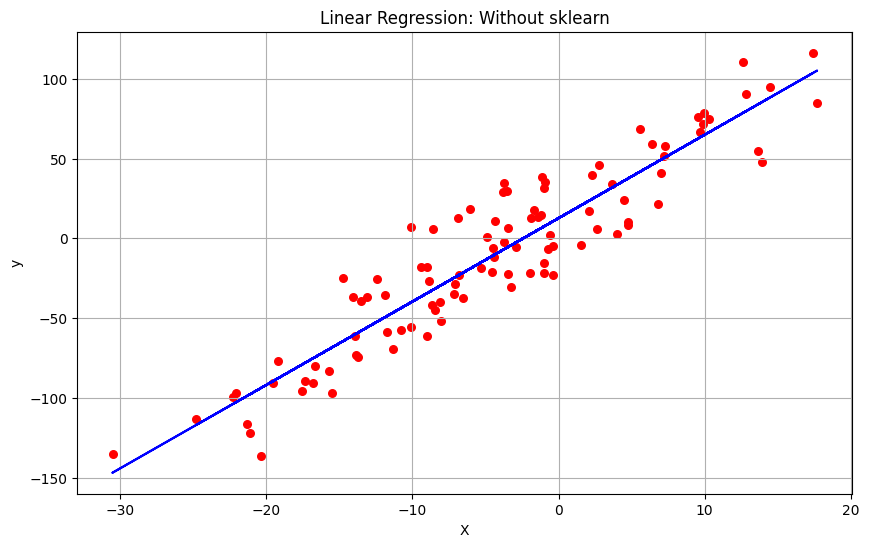

(np.float64(5.2293968670927615), np.float64(12.650046036514096))


In [ ]:
a, b = regression_coef(X, y)
coefs = (a, b)
regression_linear_plot(X, y, coefs, "Without sklearn")
print(regression_coef(X, y))

Z sklearn

In [7]:
from sklearn.linear_model import LinearRegression

In [8]:
X.shape

(100,)

In [9]:
X.reshape(-1, 1).shape

(100, 1)

In [10]:
model = LinearRegression()
model.fit(X.reshape(-1, 1), y.reshape(-1, 1))

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
print(model.coef_)

[[5.22939687]]


In [12]:
print(model.intercept_)

[12.65004604]


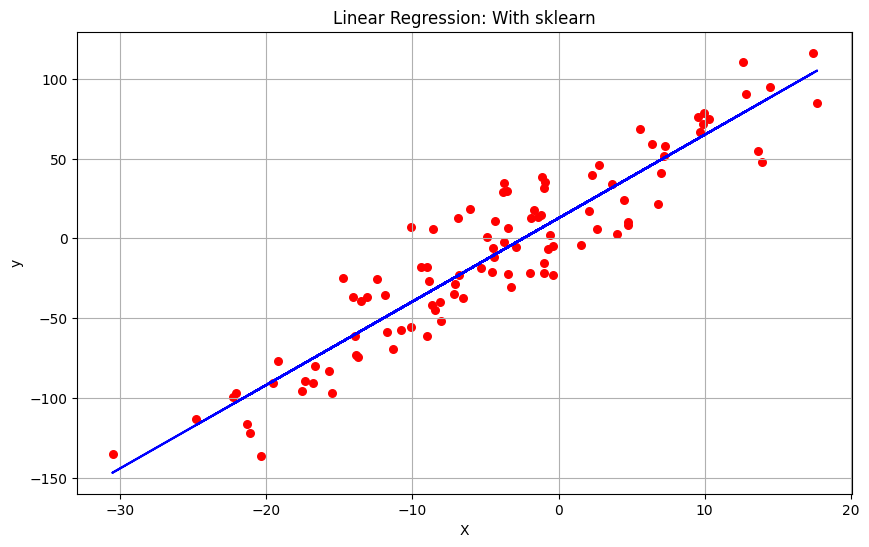

In [ ]:
a, b = model.coef_[0], model.intercept_[0]
coefs = (a, b)
regression_linear_plot(X, y, coefs, "With sklearn")

Ocena jakości

In [15]:
y_pred = model.predict(X.reshape(-1, 1))

In [17]:
R2_ = 1 - np.sum((y_pred - y.reshape(-1, 1))**2)/np.sum((y.reshape(-1, 1) - np.mean(y.reshape(-1, 1)))**2)
MSE_ = np.mean((y_pred - y.reshape(-1, 1))**2)
RMSE_ = MSE_**0.5
MAE_ = np.mean(np.abs(y_pred - y.reshape(-1, 1)))

In [19]:
print(f"R2_ = {R2_}")
print(f"MSE_ = {MSE_}")
print(f"RMSE_ = {RMSE_}")
print(f"MAE_ = {MAE_}")

R2_ = 0.8678868895945004
MSE_ = 422.8687416762516
RMSE_ = 20.56377255457402
MAE_ = 17.318782770093545


In [20]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score

R2 = r2_score(y, y_pred)
MSE = mean_squared_error(y, y_pred)
RMSE = root_mean_squared_error(y, y_pred)
MAE = mean_absolute_error(y, y_pred)

print(f"R2 = {R2}")
print(f"MSE = {MSE}")
print(f"RMSE = {RMSE}")
print(f"MAE = {MAE}")

R2 = 0.8678868895945004
MSE = 422.8687416762516
RMSE = 20.56377255457402
MAE = 17.318782770093545


In [21]:
print(f"R2_ - R2 = {R2_ - R2}")
print(f"MSE_ - MSE = {MSE_ - MSE}")
print(f"RMSE_ - RMSE = {RMSE_ - RMSE}")
print(f"MAE_ - MAE = {MAE_ - MAE}")

R2_ - R2 = 0.0
MSE_ - MSE = 0.0
RMSE_ - RMSE = 0.0
MAE_ - MAE = 0.0
